<a href="https://colab.research.google.com/github/varshitfauzdar/NLP_Assignments/blob/main/NLP(Lab8)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction

Text Summarization is one of those applications of Natural Language Processing (NLP) which is bound to have a huge impact on our lives. With growing digital media and ever growing publishing – who has the time to go through entire articles / documents / books to decide whether they are useful or not? Thankfully – this technology is already here.

Have you come across the mobile app inshorts? It’s an innovative news app that converts news articles into a 60-word summary. And that is exactly what we are going to learn in this article — Automatic Text Summarization.

Automatic Text Summarization is one of the most challenging and interesting problems in the field of Natural Language Processing (NLP). It is a process of generating a concise and meaningful summary of text from multiple text resources such as books, news articles, blog posts, research papers, emails, and tweets.

The demand for automatic text summarization systems is spiking these days thanks to the availability of large amounts of textual data.

Through this article, we will explore the realms of text summarization. We will understand how the TextRank algorithm works, and will also implement it in Python. Strap in, this is going to be a fun ride!

## Understanding the TextRank Algorithm

Before getting started with the TextRank algorithm, there’s another algorithm which we should become familiar with – the PageRank algorithm. In fact, this actually inspired TextRank! PageRank is used primarily for ranking web pages in online search results. Let’s quickly understand the basics of this algorithm with the help of an example.

![](https://cdn.analyticsvidhya.com/wp-content/uploads/2018/10/Pagerank11.png)


## TextRank Algorithm

Let’s understand the TextRank algorithm, now that we have a grasp on PageRank. I have listed the similarities between these two algorithms below:

In place of web pages, we use sentences
Similarity between any two sentences is used as an equivalent to the web page transition probability
The similarity scores are stored in a square matrix, similar to the matrix M used for PageRank
TextRank is an extractive and unsupervised text summarization technique. Let’s take a look at the flow of the TextRank algorithm that we will be following:

![](https://cdn.analyticsvidhya.com/wp-content/uploads/2018/10/block_3.png)









# 1 Importing the required Libraries

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
import numpy as np
import pandas as pd
import warnings
import re
from nltk import word_tokenize
from nltk.tokenize import sent_tokenize
from textblob import TextBlob
import string
from string import punctuation
from nltk.corpus import stopwords
from statistics import mean
from heapq import nlargest
from wordcloud import WordCloud
import seaborn as sns
import matplotlib.pyplot as plt

stop_words = set(stopwords.words('english'))
punctuation = punctuation + '\n' + '—' + '“' + ',' + '”' + '‘' + '-' + '’'
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df1 = pd.read_csv("/content/Articles.csv", encoding='latin1')
df2 = pd.read_csv("/content/News_Articles_Indian_Express.csv", encoding='latin1')

In [ ]:
print(df1.columns)
print(df2.columns)

Index(['Article', 'Date', 'Heading', 'NewsType'], dtype='object')
Index(['Unnamed: 0', 'article_id', 'headline', 'desc', 'date', 'url',
       'articles', 'article_type', 'article_length'],
      dtype='object')


In [ ]:
# Clean column names (VERY IMPORTANT)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Rename Dataset 1
df1.rename(columns={
    'Article': 'article',
    'Heading': 'headline'
}, inplace=True)

# Rename Dataset 2 (handle possible variations)
if 'articles' in df2.columns:
    df2.rename(columns={'articles': 'article'}, inplace=True)

# Check columns before selection (DEBUG step)
print("DF1 columns:", df1.columns)
print("DF2 columns:", df2.columns)

# Now select safely
df1 = df1[['article', 'headline']].dropna()

# For df2 (safe selection)
df2 = df2[['article', 'headline']].dropna()

# Combine
df = pd.concat([df1, df2], ignore_index=True)

df.head()

DF1 columns: Index(['article', 'Date', 'headline', 'NewsType'], dtype='object')
DF2 columns: Index(['Unnamed: 0', 'article_id', 'headline', 'desc', 'date', 'url',
       'article', 'article_type', 'article_length'],
      dtype='object')


,article,headline
0,KARACHI: The Sindh government has decided to b...,sindh govt decides to cut public transport far...
1,HONG KONG: Asian markets started 2015 on an up...,asia stocks up in new year trad
2,HONG KONG: Hong Kong shares opened 0.66 perce...,hong kong stocks open 0.66 percent lower
3,HONG KONG: Asian markets tumbled Tuesday follo...,asian stocks sink euro near nine year
4,NEW YORK: US oil prices Monday slipped below $...,us oil prices slip below 50 a barr


In [ ]:
# Shape of the dataset
print ("The shape of the dataset : ", df.shape)

The shape of the dataset :  (22692, 2)


In [ ]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

Text(0.5, 1.0, 'Top Words in Headlines')

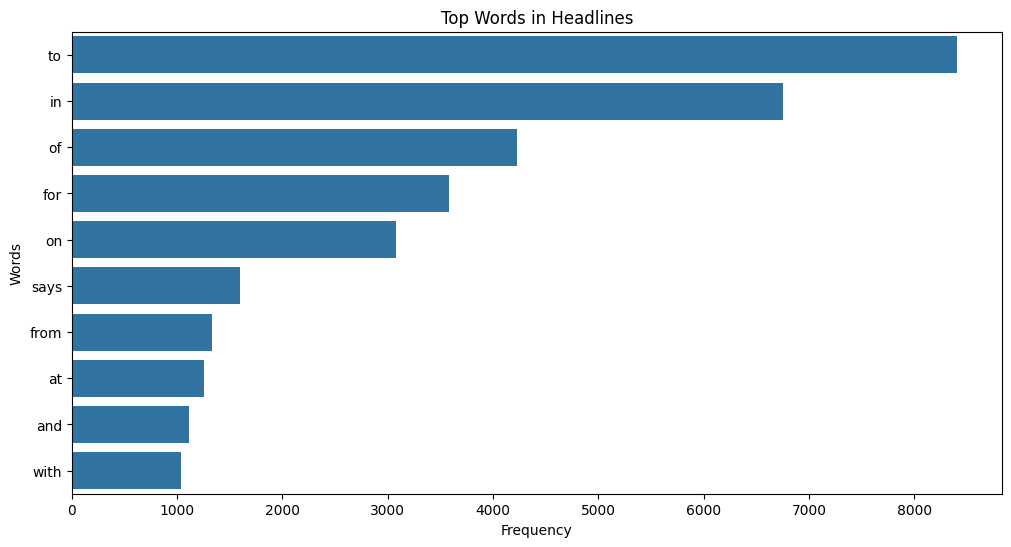

In [ ]:
from collections import Counter

text = " ".join(df['headline'].dropna())
words = text.split()

common_words = Counter(words).most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(12,6))
sns.barplot(x=counts, y=words)

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top Words in Headlines")

# 2 Exploratory Data Analysis

Text(0.5, 1.0, 'Distribution of Article Length')

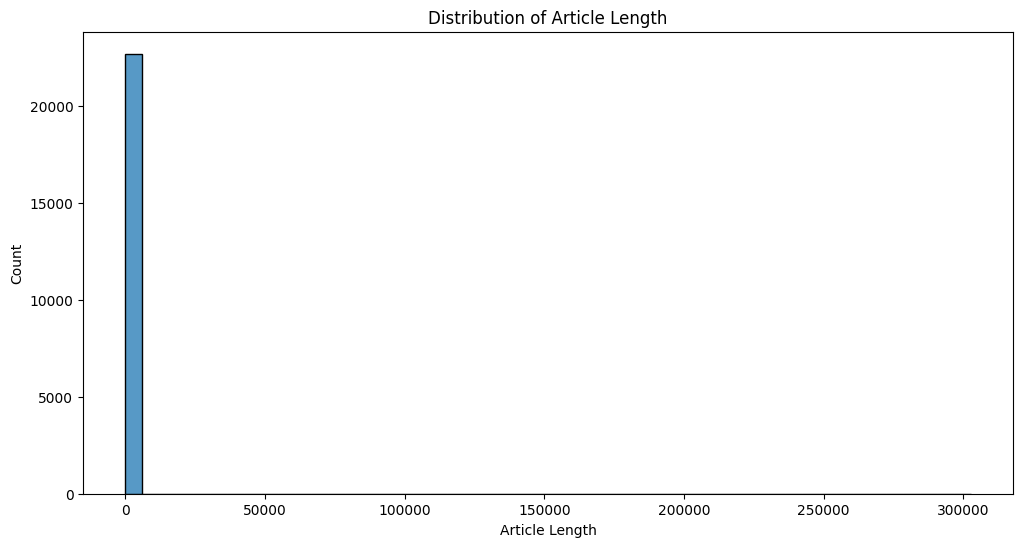

In [ ]:
df['length'] = df['article'].apply(lambda x: len(x.split()))
df['headline_length'] = df['headline'].apply(lambda x: len(x.split()))
df[['length', 'headline_length']].describe()
plt.figure(figsize=(12,6))
sns.histplot(df['length'], bins=50)

plt.xlabel("Article Length")
plt.ylabel("Count")
plt.title("Distribution of Article Length")

In [ ]:
df['length'] = df['article'].apply(lambda x: len(x.split()))
df['length'].value_counts().head()

,count
length,
308,68
396,67
272,67
295,64
274,60


In [ ]:
df['headline_length'] = df['headline'].apply(lambda x: len(x.split()))
df['headline_length'].value_counts().head()

,count
headline_length,
11,3066
12,2991
10,2915
9,2478
13,2463


# 3 Making the Article Summarizer

In [ ]:
contractions_dict = {
"ain't": "am not",
"aren't": "are not",
"can't": "cannot",
"can't've": "cannot have",
"'cause": "because",
"could've": "could have",
"couldn't": "could not",
"couldn't've": "could not have",
"didn't": "did not",
"doesn't": "does not",
"doesn’t": "does not",
"don't": "do not",
"don’t": "do not",
"hadn't": "had not",
"hadn't've": "had not have",
"hasn't": "has not",
"haven't": "have not",
"he'd": "he had",
"he'd've": "he would have",
"he'll": "he will",
"he'll've": "he will have",
"he's": "he is",
"how'd": "how did",
"how'd'y": "how do you",
"how'll": "how will",
"how's": "how is",
"i'd": "i would",
"i'd've": "i would have",
"i'll": "i will",
"i'll've": "i will have",
"i'm": "i am",
"i've": "i have",
"isn't": "is not",
"it'd": "it would",
"it'd've": "it would have",
"it'll": "it will",
"it'll've": "it will have",
"it's": "it is",
"let's": "let us",
"ma'am": "madam",
"mayn't": "may not",
"might've": "might have",
"mightn't": "might not",
"mightn't've": "might not have",
"must've": "must have",
"mustn't": "must not",
"mustn't've": "must not have",
"needn't": "need not",
"needn't've": "need not have",
"o'clock": "of the clock",
"oughtn't": "ought not",
"oughtn't've": "ought not have",
"shan't": "shall not",
"sha'n't": "shall not",
"shan't've": "shall not have",
"she'd": "she would",
"she'd've": "she would have",
"she'll": "she will",
"she'll've": "she will have",
"she's": "she is",
"should've": "should have",
"shouldn't": "should not",
"shouldn't've": "should not have",
"so've": "so have",
"so's": "so is",
"that'd": "that would",
"that'd've": "that would have",
"that's": "that is",
"there'd": "there would",
"there'd've": "there would have",
"there's": "there is",
"they'd": "they would",
"they'd've": "they would have",
"they'll": "they will",
"they'll've": "they will have",
"they're": "they are",
"they've": "they have",
"to've": "to have",
"wasn't": "was not",
"we'd": "we would",
"we'd've": "we would have",
"we'll": "we will",
"we'll've": "we will have",
"we're": "we are",
"we've": "we have",
"weren't": "were not",
"what'll": "what will",
"what'll've": "what will have",
"what're": "what are",
"what's": "what is",
"what've": "what have",
"when's": "when is",
"when've": "when have",
"where'd": "where did",
"where's": "where is",
"where've": "where have",
"who'll": "who will",
"who'll've": "who will have",
"who's": "who is",
"who've": "who have",
"why's": "why is",
"why've": "why have",
"will've": "will have",
"won't": "will not",
"won't've": "will not have",
"would've": "would have",
"wouldn't": "would not",
"wouldn't've": "would not have",
"y'all": "you all",
"y’all": "you all",
"y'all'd": "you all would",
"y'all'd've": "you all would have",
"y'all're": "you all are",
"y'all've": "you all have",
"you'd": "you would",
"you'd've": "you would have",
"you'll": "you will",
"you'll've": "you will have",
"you're": "you are",
"you've": "you have",
"ain’t": "am not",
"aren’t": "are not",
"can’t": "cannot",
"can’t’ve": "cannot have",
"’cause": "because",
"could’ve": "could have",
"couldn’t": "could not",
"couldn’t’ve": "could not have",
"didn’t": "did not",
"doesn’t": "does not",
"don’t": "do not",
"don’t": "do not",
"hadn’t": "had not",
"hadn’t’ve": "had not have",
"hasn’t": "has not",
"haven’t": "have not",
"he’d": "he had",
"he’d’ve": "he would have",
"he’ll": "he will",
"he’ll’ve": "he will have",
"he’s": "he is",
"how’d": "how did",
"how’d’y": "how do you",
"how’ll": "how will",
"how’s": "how is",
"i’d": "i would",
"i’d’ve": "i would have",
"i’ll": "i will",
"i’ll’ve": "i will have",
"i’m": "i am",
"i’ve": "i have",
"isn’t": "is not",
"it’d": "it would",
"it’d’ve": "it would have",
"it’ll": "it will",
"it’ll’ve": "it will have",
"it’s": "it is",
"let’s": "let us",
"ma’am": "madam",
"mayn’t": "may not",
"might’ve": "might have",
"mightn’t": "might not",
"mightn’t’ve": "might not have",
"must’ve": "must have",
"mustn’t": "must not",
"mustn’t’ve": "must not have",
"needn’t": "need not",
"needn’t’ve": "need not have",
"o’clock": "of the clock",
"oughtn’t": "ought not",
"oughtn’t’ve": "ought not have",
"shan’t": "shall not",
"sha’n’t": "shall not",
"shan’t’ve": "shall not have",
"she’d": "she would",
"she’d’ve": "she would have",
"she’ll": "she will",
"she’ll’ve": "she will have",
"she’s": "she is",
"should’ve": "should have",
"shouldn’t": "should not",
"shouldn’t’ve": "should not have",
"so’ve": "so have",
"so’s": "so is",
"that’d": "that would",
"that’d’ve": "that would have",
"that’s": "that is",
"there’d": "there would",
"there’d’ve": "there would have",
"there’s": "there is",
"they’d": "they would",
"they’d’ve": "they would have",
"they’ll": "they will",
"they’ll’ve": "they will have",
"they’re": "they are",
"they’ve": "they have",
"to’ve": "to have",
"wasn’t": "was not",
"we’d": "we would",
"we’d’ve": "we would have",
"we’ll": "we will",
"we’ll’ve": "we will have",
"we’re": "we are",
"we’ve": "we have",
"weren’t": "were not",
"what’ll": "what will",
"what’ll’ve": "what will have",
"what’re": "what are",
"what’s": "what is",
"what’ve": "what have",
"when’s": "when is",
"when’ve": "when have",
"where’d": "where did",
"where’s": "where is",
"where’ve": "where have",
"who’ll": "who will",
"who’ll’ve": "who will have",
"who’s": "who is",
"who’ve": "who have",
"why’s": "why is",
"why’ve": "why have",
"will’ve": "will have",
"won’t": "will not",
"won’t’ve": "will not have",
"would’ve": "would have",
"wouldn’t": "would not",
"wouldn’t’ve": "would not have",
"y’all": "you all",
"y’all": "you all",
"y’all’d": "you all would",
"y’all’d’ve": "you all would have",
"y’all’re": "you all are",
"y’all’ve": "you all have",
"you’d": "you would",
"you’d’ve": "you would have",
"you’ll": "you will",
"you’ll’ve": "you will have",
"you’re": "you are",
"you’re": "you are",
"you’ve": "you have",
}
contractions_re = re.compile('(%s)' % '|'.join(contractions_dict.keys()))

cleanhtml

In [ ]:
def cleanhtml(raw_html):
    cleanr = re.compile('<.*?>')
    cleantext = re.sub(cleanr, '', raw_html)
    return cleantext

def expand_contractions(s, contractions_dict=contractions_dict):
    def replace(match):
        return contractions_dict[match.group(0)]
    return contractions_re.sub(replace, s)

preprocessing (with hyperparameter)

In [ ]:
def preprocessing(article, remove_stopwords=True):
    global article_sent

    article = article.str.lower()
    article = article.apply(lambda x: cleanhtml(x))
    article = article.apply(lambda x: re.sub('\S+@\S+','', x))
    article = article.apply(lambda x: re.sub("http\S+|www\S+",'', x))
    article = article.apply(lambda x: x.replace("\xa0", " "))
    article = article.apply(lambda x: expand_contractions(x))

    article = article.apply(lambda x: re.sub(' +', ' ',x))

    article_sent = article.copy()

    article = article.apply(lambda x: ''.join(word for word in x if word not in punctuation))

    if remove_stopwords:
        article = article.apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))

    return article

word frequency

In [ ]:
def word_frequency(article_word, min_freq=2):
    li_word = []

    for sentence in article_word:
        word_frequency = {}

        for word in word_tokenize(sentence):
            word_frequency[word] = word_frequency.get(word, 0) + 1

        # remove rare words
        word_frequency = {k: v for k, v in word_frequency.items() if v >= min_freq}

        li_word.append(word_frequency)

    normalize(li_word)
    return normalized_freq

sentence token (NEW PARAMETER)

In [ ]:
def sent_token(article_sent, min_sent_len=5):
    sentence_list = []
    sent_token_list = []

    for sent in article_sent:
        token = sent_tokenize(sent)
        for sentence in token:
            if len(sentence.split()) >= min_sent_len:  # 🔥 filter
                token_2 = ''.join(word for word in sentence if word not in punctuation)
                token_2 = re.sub(' +', ' ',token_2)
                sent_token_list.append(token_2)
        sentence_list.append(sent_token_list)
        sent_token_list = []

    sentence_score(sentence_list)
    return sentence_score_list

summary

In [ ]:
def summary(sentence_score_OwO, ratio=0.25):
    summary_list = []

    for summ in sentence_score_OwO:
        select_length = max(1, int(len(summ) * ratio))
        summary_ = nlargest(select_length, summ, key=summ.get)
        summary_list.append(" ".join(summary_))

    return summary_list

main function

In [ ]:
def article_summarize(artefact, ratio=0.25, min_freq=2, remove_stopwords=True, min_sent_len=5):

    if type(artefact) != pd.Series:
        artefact = make_series(artefact)

    df_clean = preprocessing(artefact, remove_stopwords)

    word_normalization = word_frequency(df_clean, min_freq)

    sentence_score_OwO = sent_token(article_sent, min_sent_len)

    summarized_article = summary(sentence_score_OwO, ratio)

    return summarized_article

normalize

In [ ]:
def normalize(li_word):
    global normalized_freq
    normalized_freq = []

    for dictionary in li_word:
        if len(dictionary) == 0:
            normalized_freq.append(dictionary)
            continue

        max_frequency = max(dictionary.values())

        for word in dictionary.keys():
            dictionary[word] = dictionary[word] / max_frequency

        normalized_freq.append(dictionary)

    return normalized_freq

sent_token

In [ ]:
def sentence_score(li):
    global sentence_score_list
    sentence_score_list = []

    for list_, dictionary in zip(li, normalized_freq):
        sentence_score = {}

        for sent in list_:
            for word in word_tokenize(sent):
                if word in dictionary.keys():
                    if sent not in sentence_score:
                        sentence_score[sent] = dictionary[word]
                    else:
                        sentence_score[sent] += dictionary[word]

        sentence_score_list.append(sentence_score)

    return sentence_score_list

HYPERPARAMETER TUNING

In [ ]:
import pandas as pd

results = []

ratios = [0.2, 0.25, 0.3]
min_freqs = [1, 2]
stopword_options = [True, False]
sent_lengths = [3, 5]

for r in ratios:
    for mf in min_freqs:
        for sw in stopword_options:
            for sl in sent_lengths:

                summaries = article_summarize(
                    df['article'][0:5],
                    ratio=r,
                    min_freq=mf,
                    remove_stopwords=sw,
                    min_sent_len=sl
                )

                avg_len = sum(len(s.split()) for s in summaries) / len(summaries)

                results.append({
                    "ratio": r,
                    "min_freq": mf,
                    "stopwords": sw,
                    "min_sent_len": sl,
                    "avg_summary_length": avg_len
                })

# Create table
results_df = pd.DataFrame(results)

results_df

,ratio,min_freq,stopwords,min_sent_len,avg_summary_length
0,0.20,1,True,3,192.0
1,0.20,1,True,5,192.0
2,0.20,1,False,3,206.2
3,0.20,1,False,5,206.2
4,0.20,2,True,3,192.0
5,0.20,2,True,5,192.0
6,0.20,2,False,3,206.2
7,0.20,2,False,5,206.2
8,0.25,1,True,3,192.0
9,0.25,1,True,5,192.0


In [ ]:
def make_series(art):
    data_dict = {'article': [art]}
    return pd.DataFrame(data_dict)['article']

In [ ]:
summary1 = article_summarize(df['article'][10], ratio=0.2)
summary2 = article_summarize(df['article'][10], ratio=0.25)
summary3 = article_summarize(df['article'][10], ratio=0.3)
print("Short Summary:\n", summary1[0])
print("\nMedium Summary:\n", summary2[0])
print("\nLong Summary:\n", summary3[0])

Short Summary:
 tokyo tokyo stocks opened 074 percent lower on wednesday hit by the yen´s rise and drops on wall street on worries about falling oil pricesthe nikkei 225 index at the tokyo stock exchange lost 12589 to 1696182 at the startin new york on tuesday the dow jones industrial average dropped 015 percent and the broadbased sp 500 fell 026 percent overshadowed by worries about sliding crude oil pricesthe yen rose against other currencies on safehaven buying a negative for japanese exporters as the stronger currency makes them less competitive abroad and erodes profits when repatriatedthe dollar was at 11772 yen early wednesday down from 11790 yen in new york tuesday afternoon and rates above 118 yen seen in tokyo earlier tuesdaythe euro also fell after a key european central banker expressed support for monetary stimulusthe common european currency bought 13869 yen and 11776 against 13884 yen and 11777 in us tradethe ruble´s drop took a breather early wednesday after plunging by

In [ ]:
# Short summary
summary1 = article_summarize(df['article'][0], ratio=0.2, min_freq=2)

# Medium summary
summary2 = article_summarize(df['article'][0], ratio=0.25, min_freq=1)

# Long summary
summary3 = article_summarize(df['article'][0], ratio=0.3, min_freq=1, remove_stopwords=False)

print("Short Summary:\n", summary1[0])
print("\nMedium Summary:\n", summary2[0])
print("\nLong Summary:\n", summary3[0])

Short Summary:
 karachi the sindh government has decided to bring down public transport fares by 7 per cent due to massive reduction in petroleum product prices by the federal government geo news reportedsources said reduction in fares will be applicable on public transport rickshaw taxi and other means of travelingmeanwhile karachi transport ittehad kti has refused to abide by the government decisionkti president irshad bukhari said the commuters are charged the lowest fares in karachi as compare to other parts of the country adding that 80pc vehicles run on compressed natural gas cng

Medium Summary:
 karachi the sindh government has decided to bring down public transport fares by 7 per cent due to massive reduction in petroleum product prices by the federal government geo news reportedsources said reduction in fares will be applicable on public transport rickshaw taxi and other means of travelingmeanwhile karachi transport ittehad kti has refused to abide by the government decisionk

In [ ]:
import re

article_text = df['article'].iloc[0]

formatted_text = re.sub(r'\.(?=[A-Z])', '.\n', article_text)

print(formatted_text[:1000])

KARACHI: The Sindh government has decided to bring down public transport fares by 7 per cent due to massive reduction in petroleum product prices by the federal government, Geo News reported.
Sources said reduction in fares will be applicable on public transport, rickshaw, taxi and other means of traveling.
Meanwhile, Karachi Transport Ittehad (KTI) has refused to abide by the government decision.
KTI President Irshad Bukhari said the commuters are charged the lowest fares in Karachi as compare to other parts of the country, adding that 80pc vehicles run on Compressed Natural Gas (CNG). Bukhari said Karachi transporters will cut fares when decrease in CNG prices will be made.                        













In [ ]:
import re

summary_text = summaries[0]

# Add newline after sentences
formatted_summary = re.sub(r'\.(?=[A-Z])', '.\n', summary_text)

print("Character length:", len(summary_text))
print("Word count:", len(summary_text.split()))

print("\nFormatted Summary:\n")
print(formatted_summary[:1000])

Character length: 576
Word count: 91

Formatted Summary:

karachi the sindh government has decided to bring down public transport fares by 7 per cent due to massive reduction in petroleum product prices by the federal government geo news reportedsources said reduction in fares will be applicable on public transport rickshaw taxi and other means of travelingmeanwhile karachi transport ittehad kti has refused to abide by the government decisionkti president irshad bukhari said the commuters are charged the lowest fares in karachi as compare to other parts of the country adding that 80pc vehicles run on compressed natural gas cng


In [ ]:
original = df['article'].iloc[0]

print("Original words:", len(original.split()))
print("Summary words:", len(summary_text.split()))

Original words: 106
Summary words: 91
